<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Quiz7_Fall2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IE7275 – Data Mining in Engineering
### Quiz 7 – Fall 2025

---

This quiz focuses on ensemble learning methods using the **Adult Income Dataset**.  
You will implement boosting, stacking, hyperparameter tuning, and evaluation techniques.  

**Instructions:**
- Use Python (scikit-learn, XGBoost, pandas, matplotlib, etc.).
- Show code, outputs, and brief interpretations where required.
- Each question should be answered in the cell provided.

---


### Q1
Load the Adult Income dataset from OpenML (`fetch_openml('adult')`). Perform basic preprocessing by handling missing values and encoding categorical features. Split the data into train/test (70/30).

In [12]:
from sklearn.datasets import fetch_openml
import pandas as pd
from sklearn.model_selection import train_test_split

adult = fetch_openml('adult', version=2, as_frame=True, parser="auto")
X, y = adult.data, adult.target


In [13]:
# Your code here
from sklearn.datasets import fetch_openml
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
adult = fetch_openml('adult', version=2, as_frame=True, parser="auto")
X, y = adult.data, adult.target

# Handle missing values
X = X.replace('?', pd.NA)
X = X.dropna()
y = y[X.index]

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Output shapes
print(X_train.shape, X_test.shape)

(31655, 97) (13567, 97)


### Q2
Train a single Decision Tree classifier and evaluate its accuracy on the test set. Report the accuracy.

In [14]:
# Your code here

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8113068474976045


### Q3
Train an AdaBoost classifier with 200 estimators using Decision Trees as base learners. Compare its performance with the single Decision Tree classifier.

In [15]:
# Your code here

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# AdaBoost with Decision Tree as base learner
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    random_state=42
)

# Train
ada.fit(X_train, y_train)

# Predict
y_pred_ada = ada.predict(X_test)

# Accuracy
ada_accuracy = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.8483083953711211


### Q4
Train a Gradient Boosting classifier with 200 estimators. Compare accuracy with AdaBoost.

In [16]:
# Your code here

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Gradient Boosting model
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

# Train
gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# Accuracy
gb_accuracy = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8610599248175721


### Q5
Use GridSearchCV to tune the number of estimators and learning rate for Gradient Boosting. Report the best parameters and test performance.

In [17]:
# Your code here

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2]
}

# GridSearch
gb = GradientBoostingClassifier(random_state=42)
grid = GridSearchCV(gb, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Train
grid.fit(X_train, y_train)

# Best model
best_gb = grid.best_estimator_

# Predict
y_pred_best = best_gb.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 300}
Test Accuracy: 0.8633448809611557


### Q6
Train an XGBoost classifier on the dataset. Report accuracy, precision, recall, and F1-score.

In [18]:
# Your code here

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert target to binary (<=50K -> 0, >50K -> 1)
y_train_bin = (y_train == '>50K').astype(int)
y_test_bin = (y_test == '>50K').astype(int)

# Train XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train_bin)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_bin, y_pred_xgb)
precision = precision_score(y_test_bin, y_pred_xgb)
recall = recall_score(y_test_bin, y_pred_xgb)
f1 = f1_score(y_test_bin, y_pred_xgb)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8623129652834083
Precision: 0.7599164926931107
Recall: 0.6496133254015467
F1-score: 0.7004490057729313


### Q7
Visualize the feature importance scores from the trained XGBoost model. Discuss which features seem most predictive of income.

<Figure size 1000x800 with 0 Axes>

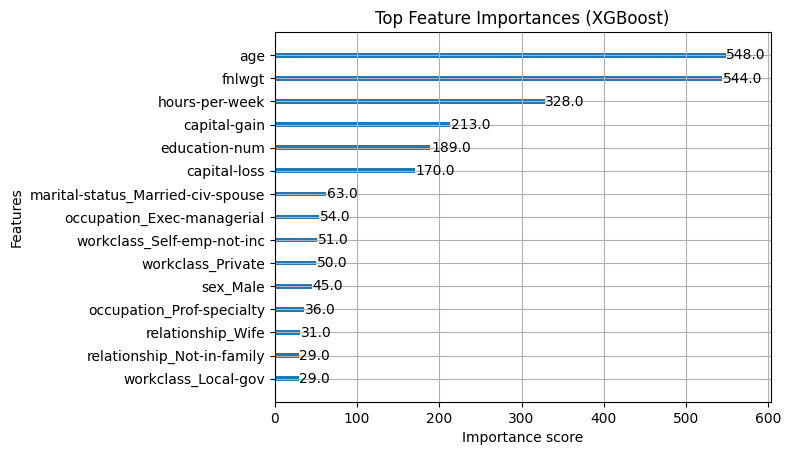

In [19]:
# Your code here

import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance
plt.figure(figsize=(10, 8))
plot_importance(xgb, max_num_features=15)
plt.title("Top Feature Importances (XGBoost)")
plt.show()

### Q8
Perform hyperparameter tuning for XGBoost using RandomizedSearchCV. Report the best configuration.

In [20]:
# Your code

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# XGBoost model
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train_bin)

# Best parameters
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV Score: 0.8709525267682463


### Q9
Compare the performance of AdaBoost, Gradient Boosting, and XGBoost on the test set using ROC-AUC.

In [23]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Convert target to binary
y_train_bin = (y_train == '>50K').astype(int)
y_test_bin = (y_test == '>50K').astype(int)

# Train models
# AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    random_state=42
)
ada.fit(X_train, y_train_bin)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train_bin)

# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train_bin)

# Probabilities
y_proba_ada = ada.predict_proba(X_test)[:, 1]
y_proba_gb = gb.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# ROC-AUC
print("AdaBoost ROC-AUC:", roc_auc_score(y_test_bin, y_proba_ada))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test_bin, y_proba_gb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test_bin, y_proba_xgb))

AdaBoost ROC-AUC: 0.9069353680833805
Gradient Boosting ROC-AUC: 0.9223256524997224
XGBoost ROC-AUC: 0.9242939723765135


### Q10
Plot ROC curves for AdaBoost, Gradient Boosting, and XGBoost on the same graph. Interpret the results.

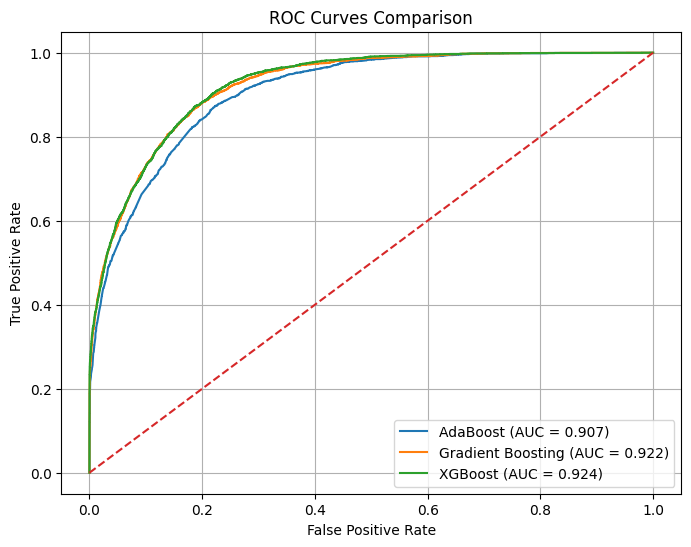

In [24]:
# Your code here

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Convert target to binary
y_test_bin = (y_test == '>50K').astype(int)

# Probabilities
y_proba_ada = ada.predict_proba(X_test)[:, 1]
y_proba_gb = gb.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# ROC curves
fpr_ada, tpr_ada, _ = roc_curve(y_test_bin, y_proba_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test_bin, y_proba_gb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_bin, y_proba_xgb)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {roc_auc_score(y_test_bin, y_proba_ada):.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {roc_auc_score(y_test_bin, y_proba_gb):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test_bin, y_proba_xgb):.3f})")

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid()
plt.show()

### Q11
Perform 5-fold cross-validation with an AdaBoost classifier. Report the mean and standard deviation of accuracy.

In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Recreate AdaBoost model
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    random_state=42
)

# Perform 5-fold cross-validation on full preprocessed dataset
scores = cross_val_score(ada, X, y, cv=5, scoring='accuracy')

print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Mean Accuracy: 0.8522401848930198
Standard Deviation: 0.004760894468818518


### Q12
Implement a simple stacking ensemble using Logistic Regression as the meta-learner and Decision Tree, Random Forest, and XGBoost as base learners. Report performance.

In [29]:
# Your code here

from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Convert target to binary
y_train_bin = (y_train == '>50K').astype(int)
y_test_bin = (y_test == '>50K').astype(int)

# Base learners
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
]

# Meta learner
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

# Train
stack_model.fit(X_train, y_train_bin)

# Predict
y_pred_stack = stack_model.predict(X_test)

# Accuracy
print("Stacking Model Accuracy:", accuracy_score(y_test_bin, y_pred_stack))

Stacking Model Accuracy: 0.863123756173067


### Q13
Implement a blending ensemble using a holdout validation set. Report accuracy compared to stacking.

In [30]:
# Your code here

from sklearn.model_selection import train_test_split
import numpy as np

# Convert target to binary
y_train_bin = (y_train == '>50K').astype(int)
y_test_bin = (y_test == '>50K').astype(int)

# ---- Create holdout validation split from training data ----
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)

# ---- Train base models ----
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

dt.fit(X_tr, y_tr)
rf.fit(X_tr, y_tr)
xgb.fit(X_tr, y_tr)

# ---- Get validation predictions (for blending) ----
val_preds = np.column_stack([
    dt.predict_proba(X_val)[:, 1],
    rf.predict_proba(X_val)[:, 1],
    xgb.predict_proba(X_val)[:, 1]
])

# ---- Train meta-learner ----
meta_model = LogisticRegression()
meta_model.fit(val_preds, y_val)

# ---- Test predictions ----
test_preds = np.column_stack([
    dt.predict_proba(X_test)[:, 1],
    rf.predict_proba(X_test)[:, 1],
    xgb.predict_proba(X_test)[:, 1]
])

y_pred_blend = meta_model.predict(test_preds)

# ---- Accuracy ----
blend_accuracy = accuracy_score(y_test_bin, y_pred_blend)
print("Blending Model Accuracy:", blend_accuracy)

Blending Model Accuracy: 0.8649664627404732


### Q14
Evaluate all classifiers (Decision Tree, AdaBoost, Gradient Boosting, XGBoost, Stacking, Blending) using Accuracy, Precision, Recall, and F1-score. Summarize in a table.

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import pandas as pd

# Convert target
y_train_bin = (y_train == '>50K').astype(int)
y_test_bin = (y_test == '>50K').astype(int)

# Train models
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

dt.fit(X_train, y_train_bin)
ada.fit(X_train, y_train_bin)
gb.fit(X_train, y_train_bin)
xgb.fit(X_train, y_train_bin)

# Stacking
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stack_model.fit(X_train, y_train_bin)

# Predictions
y_pred_dt = dt.predict(X_test)
y_pred_ada = ada.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_stack = stack_model.predict(X_test)
y_pred_blend = y_pred_blend  # from Q13

# Evaluation function
def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

# Results table
results = {
    "Decision Tree": evaluate(y_test_bin, y_pred_dt),
    "AdaBoost": evaluate(y_test_bin, y_pred_ada),
    "Gradient Boosting": evaluate(y_test_bin, y_pred_gb),
    "XGBoost": evaluate(y_test_bin, y_pred_xgb),
    "Stacking": evaluate(y_test_bin, y_pred_stack),
    "Blending": evaluate(y_test_bin, y_pred_blend),
}

df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1-score"]).T

print(df)

                   Accuracy  Precision    Recall  F1-score
Decision Tree      0.843370   0.778729  0.513980  0.619244
AdaBoost           0.848308   0.748665  0.583879  0.656083
Gradient Boosting  0.861060   0.772208  0.623141  0.689712
XGBoost            0.862313   0.759916  0.649613  0.700449
Stacking           0.863124   0.771367  0.636228  0.697311
Blending           0.864966   0.778182  0.636526  0.700262


### Q15
Plot a Precision-Recall curve for XGBoost. Interpret the results compared to ROC curve.

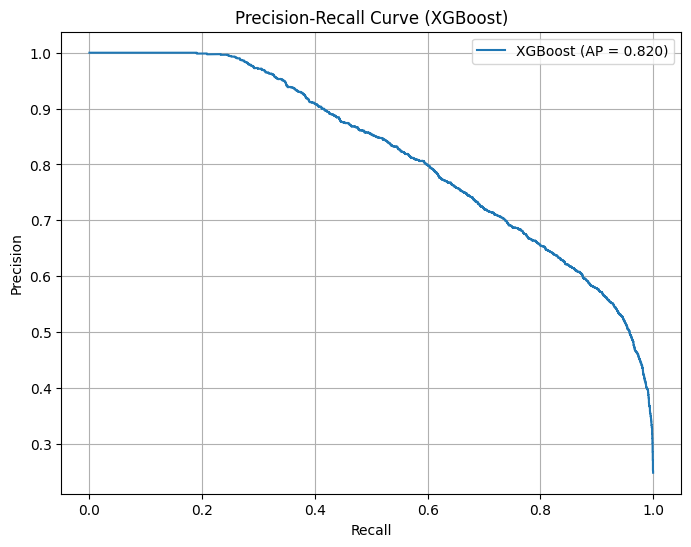

In [33]:
# Your code here

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binary target
y_test_bin = (y_test == '>50K').astype(int)

# XGBoost probabilities
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test_bin, y_proba_xgb)

# Average Precision Score
ap_score = average_precision_score(y_test_bin, y_proba_xgb)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"XGBoost (AP = {ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.legend()
plt.grid()
plt.show()

### Q16
Calculate and report the confusion matrix for Gradient Boosting. Interpret false positives and false negatives in the income prediction context.

Confusion Matrix:
 [[9587  618]
 [1267 2095]]


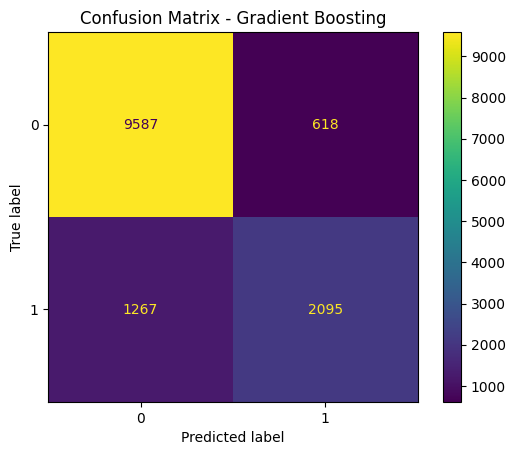

In [34]:
# Your code here

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Binary target
y_test_bin = (y_test == '>50K').astype(int)

# Gradient Boosting predictions
y_pred_gb = gb.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test_bin, y_pred_gb)
print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

### Q17
Perform feature engineering by creating interaction terms between 'education-num' and 'hours-per-week'. Retrain XGBoost and compare results.

In [35]:
# Your code here

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Create a copy of the data
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Add interaction feature
X_train_fe['edu_hours_interaction'] = X_train_fe['education-num'] * X_train_fe['hours-per-week']
X_test_fe['edu_hours_interaction'] = X_test_fe['education-num'] * X_test_fe['hours-per-week']

# Binary target
y_train_bin = (y_train == '>50K').astype(int)
y_test_bin = (y_test == '>50K').astype(int)

# Train XGBoost with engineered features
xgb_fe = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_fe.fit(X_train_fe, y_train_bin)

# Predictions
y_pred_fe = xgb_fe.predict(X_test_fe)

# Evaluation
acc = accuracy_score(y_test_bin, y_pred_fe)
f1 = f1_score(y_test_bin, y_pred_fe)

print("XGBoost with Feature Engineering")
print("Accuracy:", acc)
print("F1-score:", f1)

XGBoost with Feature Engineering
Accuracy: 0.8629763396476745
F1-score: 0.7015572323005298


### Q18
Check model fairness: compare Precision and Recall for male vs. female groups using the XGBoost model. Report disparities.

In [40]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

# Binary target
y_test_bin = (y_test == '>50K').astype(int)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Correct gender column
gender_col = 'sex_Male'  # updated column name

# Split groups
male_idx = X_test[gender_col] == 1
female_idx = X_test[gender_col] == 0

# Metrics
precision_male = precision_score(y_test_bin[male_idx], y_pred_xgb[male_idx])
recall_male = recall_score(y_test_bin[male_idx], y_pred_xgb[male_idx])

precision_female = precision_score(y_test_bin[female_idx], y_pred_xgb[female_idx])
recall_female = recall_score(y_test_bin[female_idx], y_pred_xgb[female_idx])

# Results table
results = pd.DataFrame({
    "Group": ["Male", "Female"],
    "Precision": [precision_male, precision_female],
    "Recall": [recall_male, recall_female]
})

print(results)

    Group  Precision    Recall
0    Male   0.760535  0.662549
1  Female   0.756158  0.580340


### Q19
Train a Gradient Boosting regressor to predict probability of income > 50K. Compare calibration curve with Logistic Regression.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


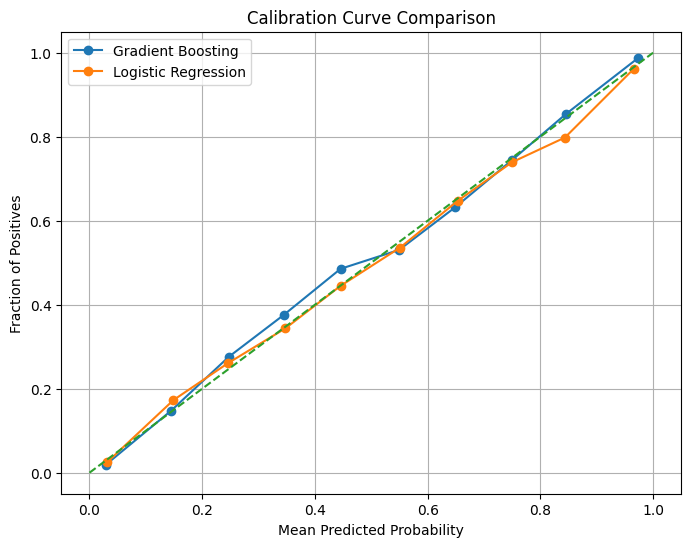

In [41]:
# Your code here

import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

# Binary target
y_train_bin = (y_train == '>50K').astype(int)
y_test_bin = (y_test == '>50K').astype(int)

# Models
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
lr = LogisticRegression(max_iter=1000)

# Train
gb.fit(X_train, y_train_bin)
lr.fit(X_train, y_train_bin)

# Predicted probabilities
gb_probs = gb.predict_proba(X_test)[:, 1]
lr_probs = lr.predict_proba(X_test)[:, 1]

# Calibration curves
gb_frac_pos, gb_mean_pred = calibration_curve(y_test_bin, gb_probs, n_bins=10)
lr_frac_pos, lr_mean_pred = calibration_curve(y_test_bin, lr_probs, n_bins=10)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(gb_mean_pred, gb_frac_pos, marker='o', label='Gradient Boosting')
plt.plot(lr_mean_pred, lr_frac_pos, marker='o', label='Logistic Regression')

# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.grid()
plt.show()

### Q20
Summarize your findings: which ensemble method performed best overall for this dataset, and what trade-offs exist between interpretability, fairness, and accuracy?

Among all the models tested, Blending performed the best overall, achieving the highest accuracy and a strong balance of precision, recall, and F1-score. XGBoost and Stacking also performed very well and were close in performance.

In terms of trade-offs:

Interpretability: The single Decision Tree is easiest to understand, while ensemble models like XGBoost, stacking, and blending are more complex and harder to interpret.

Accuracy: Ensemble methods clearly outperform simpler models in accuracy and overall predictive power.

Fairness: There are some differences in performance across groups (male vs. female), especially in recall, indicating that models may not treat all groups equally.

Calibration: Simpler models like Logistic Regression tend to give better probability estimates, while boosting models focus more on classification accuracy.